In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df= pd.read_csv(path + "/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [7]:
df['longitud_review'] = df['review'].apply(lambda x: len(x.split()))

df['longitud_review'].describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: longitud_review, dtype: float64

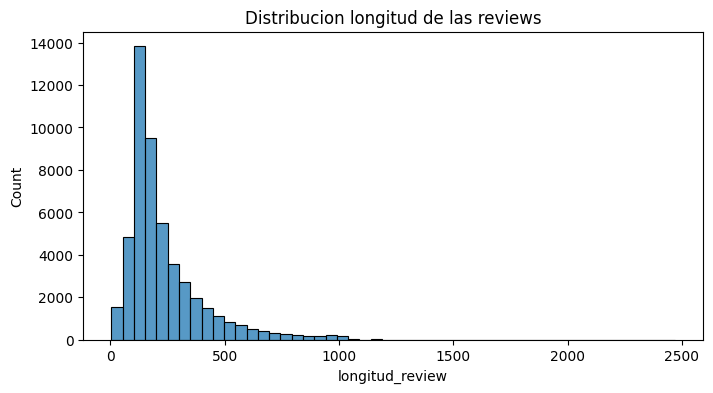

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df['longitud_review'], bins=50)
plt.title("Distribucion longitud de las reviews")
plt.show()

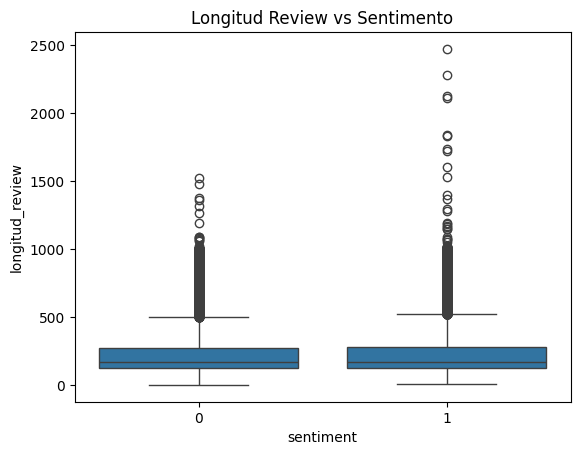

In [9]:
sns.boxplot(x='sentiment', y='longitud_review', data=df)
plt.title("Longitud Review vs Sentimento")
plt.show()

In [10]:
print("Ejemplo de review positiva:\n")
print(df[df['sentiment'] == 1]['review'].iloc[0])

print("\nEjemplo de review negativa:\n")
print(df[df['sentiment'] == 0]['review'].iloc[0])

Ejemplo de review positiva:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal 

In [11]:
from bs4 import BeautifulSoup
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Conjunto de stopwords en inglés de scikit-learn (es un frozenset)
stop_words = set(ENGLISH_STOP_WORDS)

# Función de limpieza
def preprocess(text):
    # Eliminar etiquetas HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación (deja solo letras, números y espacios)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Tokenizar por espacios y filtrar stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# Crear nueva columna limpia
df['review'] = df['review'].apply(preprocess)

# Verificar resultado

print("\nEjemplo de review negativa limpia:\n")
print(df[df['sentiment'] == 0]['review'].iloc[0])




Ejemplo de review negativa limpia:

basically s family little boy jake thinks s zombie closet parents fighting time movie slower soap opera suddenly jake decides rambo kill zombie ok going make film decide thriller drama drama movie watchable parents divorcing arguing like real life jake closet totally ruins film expected boogeyman similar movie instead watched drama meaningless thriller spots 3 10 just playing parents descent dialogs shots jake just ignore


Tamaño del entrenamiento: (40000,)
Tamaño de prueba: (10000,)
Mejores parámetros (LR): {'C': 1}
Mejor score (CV): 0.888575
Accuracy en test: 0.8944
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.89      0.91      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Matriz de Confusión - Regresión Logística:


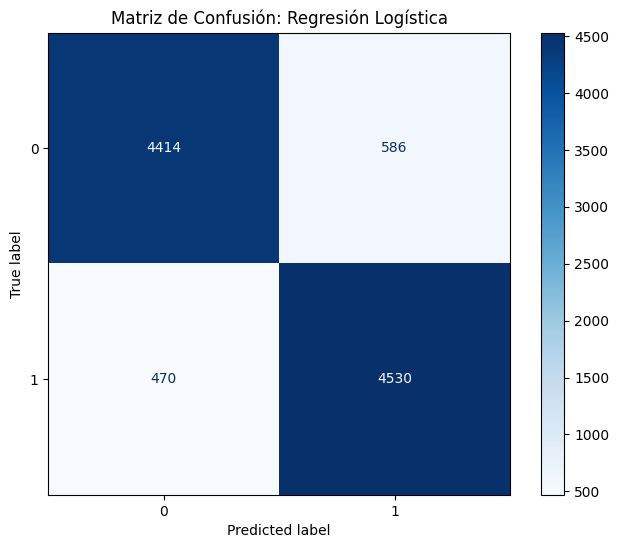

In [12]:
# Modelos de Scikit-Learn
from sklearn.linear_model import LogisticRegression
# Métricas y validación
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split

X = df['review']
y = df['sentiment']

CEDULA = 21534219 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=CEDULA, stratify=y
)

print("Tamaño del entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)  # puedes ajustar max_features
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


param_grid_lr = {'C': [0.01, 0.1, 1, 10]}
lr = LogisticRegression(random_state=CEDULA)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

print("Mejores parámetros (LR):", grid_lr.best_params_)
print("Mejor score (CV):", grid_lr.best_score_)


y_pred = grid_lr.predict(X_test_tfidf)
print("Accuracy en test:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("Matriz de Confusión - Regresión Logística:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_lr, X_test_tfidf, y_test, 
                                      cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Regresión Logística')
plt.show()

--- Support Vector Machine (LinearSVC) ---
Mejores parámetros: {'C': 0.1}
Accuracy en test: 0.8951
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      5000
           1       0.88      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



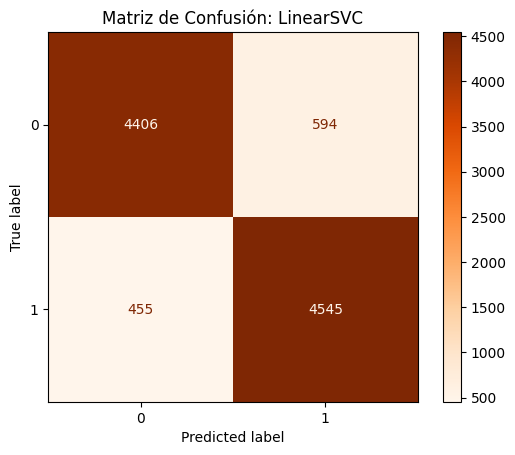

In [13]:
from sklearn.svm import LinearSVC

# Definir la grilla de parámetros para SVM
param_grid_svm = {'C': [0.1, 1, 10]}
svm = LinearSVC(random_state=CEDULA, max_iter=2000)

# Búsqueda de hiperparámetros
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_tfidf, y_train)

# Predicción y evaluación
y_pred_svm = grid_svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("--- Support Vector Machine (LinearSVC) ---")
print(f"Mejores parámetros: {grid_svm.best_params_}")
print(f"Accuracy en test: {acc_svm}")
print(classification_report(y_test, y_pred_svm))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, 
                                        display_labels=['0', '1'], 
                                        cmap='Oranges')
plt.title('Matriz de Confusión: LinearSVC')
plt.show()

Comparativa de Modelos:
                Modelo  Accuracy Test
1            LinearSVC         0.8951
0  Logistic Regression         0.8944


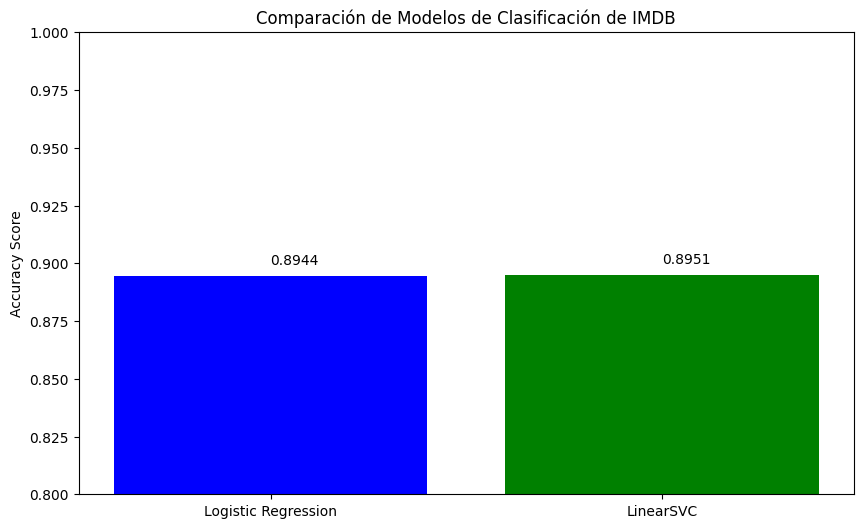

In [14]:
import pandas as pd

# Crear un resumen de los resultados
resultados = {
    'Modelo': ['Logistic Regression', 'LinearSVC'],
    'Accuracy Test': [accuracy_score(y_test, y_pred), acc_svm]
}

df_comparativo = pd.DataFrame(resultados)
print("Comparativa de Modelos:")
print(df_comparativo.sort_values(by='Accuracy Test', ascending=False))

# Gráfico de barras para la presentación
plt.figure(figsize=(10, 6))
plt.bar(df_comparativo['Modelo'], df_comparativo['Accuracy Test'], color=['blue', 'green', 'orange'])
plt.ylim(0.8, 1.0) # Ajustar para ver mejor las diferencias
plt.ylabel('Accuracy Score')
plt.title('Comparación de Modelos de Clasificación de IMDB')
for i, val in enumerate(df_comparativo['Accuracy Test']):
    plt.text(i, val + 0.005, f'{val:.4f}')
plt.show()